# Melanoma treatment combinations

Explore how individual and combined treatments affect melanocyte dynamics.

- **BRAF inhibitors**: block BRAF/MEK/ERK → reduce intrinsic proliferation → `pM ÷ fold`
- **Immunotherapy**: enhance immune killing → increase death rate → `death × fold`

In [1]:
%load_ext autoreload
%autoreload 2

from scipy.integrate import odeint
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

GRAY = '#808080'

## Dimensionless model

```
dD/dτ = ρ₁·UV/m − ρ₂·D
dm/dτ = ρ₃·M·D − ρ₄·m
dα/dτ = ρ₈·(D − 1)              (fibroblast epigenetic memory, D*=1)
dM/dτ = M·(ρ₅/braf + ρ₆·α·D + ρ₇·D − immuno)
```

- `braf_fold = 1` → no BRAF treatment; `braf_fold = k` → pM divided by k
- `immuno_fold = 1` → no immunotherapy; `immuno_fold = k` → death rate multiplied by k
- Integral feedback on D (via α) drives perfect adaptation back to D*=1

In [2]:
def removal_rate_from_turnover_time(turnover_time):
    return np.log(2) / (turnover_time / 5)


def get_params(p5=1/3, p6=1/3, p7=1/3, p8=None, uv=1):
    rD = removal_rate_from_turnover_time(1/7)   # 1-day
    rm = removal_rate_from_turnover_time(4)      # 1-month
    rM = removal_rate_from_turnover_time(52)     # 1-year
    p2 = rD / rM
    p4 = rm / rM
    p8 = p8 or 1 / (5 * np.log(2))
    return dict(p1=p2, p2=p2, p3=p4, p4=p4, p5=p5, p6=p6, p7=p7, p8=p8, uv=uv)


def get_f(params, braf_fold=1, immuno_fold=1):
    p1, p2, p3, p4 = params['p1'], params['p2'], params['p3'], params['p4']
    p5, p6, p7, p8 = params['p5'], params['p6'], params['p7'], params['p8']
    uv = params['uv']

    def f(x, t):
        D, m, a, M = x
        dD = p1 * uv / m - p2 * D
        dm = p3 * M * D - p4 * m
        da = p8 * D - p8
        dM = M * (p5 / braf_fold + p6 * a * D + p7 * D - immuno_fold)
        return [dD, dm, da, dM]
    return f


def get_steady_state(params):
    f = get_f(params)
    t = np.linspace(0, 1000, 2000)
    sol = odeint(f, [1.0, 1.0, 1.0, 1.0], t)
    return sol[-1]


defaults = get_params()
x0 = get_steady_state(defaults)
print(f'steady state: D={x0[0]:.4f}, m={x0[1]:.4f}, α={x0[2]:.4f}, M={x0[3]:.4f}')

steady state: D=1.0000, m=1.0000, α=1.0000, M=1.0000


## Simulation helper

In [3]:
def simulate_treatment(params, duration, braf_fold=1, immuno_fold=1):
    """Two-phase: run to steady state, then apply treatment for same duration."""
    x0 = get_steady_state(params)
    t1 = np.linspace(0, duration, 400)
    sol1 = odeint(get_f(params), x0, t1)
    t2 = np.linspace(duration, duration * 2, 400)
    sol2 = odeint(get_f(params, braf_fold=braf_fold, immuno_fold=immuno_fold), sol1[-1], t2)
    return np.concatenate([t1, t2]), np.vstack([sol1, sol2]), t1, t2

## BRAF inhibitor: pM ÷ fold

Reduces intrinsic proliferation rate ρ₅. The integral feedback (α) will eventually compensate by upregulating HGF-driven growth, restoring M to baseline.

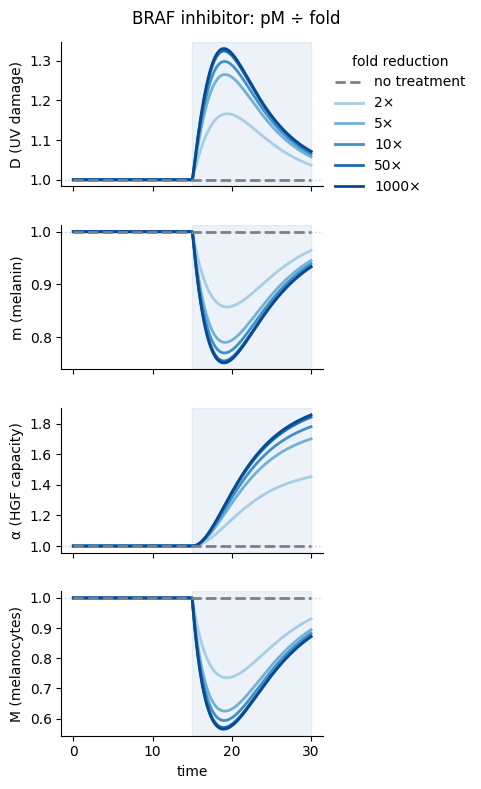

In [4]:
duration = 15
braf_folds = [2, 5, 10, 50, 1000]
blues = [plt.get_cmap('Blues')(v) for v in np.linspace(0.35, 0.9, len(braf_folds))]

t_base, sol_base, t1_base, t2_base = simulate_treatment(defaults, duration)

var_labels = ['D (UV damage)', 'm (melanin)', 'α (HGF capacity)', 'M (melanocytes)']
fig, axs = plt.subplots(4, 1, figsize=(5, 8), sharex=True)

for i, (ax, label) in enumerate(zip(axs, var_labels)):
    ax.axvspan(duration, duration * 2, alpha=0.1, color='steelblue')
    ax.axhline(1, color=GRAY, ls=':', lw=1, alpha=0.4)
    ax.plot(t_base, sol_base[:, i], color=GRAY, lw=2, ls='--', label='no treatment', zorder=5)
    ax.set_ylabel(label)
    sns.despine(ax=ax)

for fold, color in zip(braf_folds, blues):
    t, sol, _, _ = simulate_treatment(defaults, duration, braf_fold=fold)
    for i, ax in enumerate(axs):
        ax.plot(t, sol[:, i], color=color, lw=2, label=f'{fold}×')

axs[0].legend(frameon=False, title='fold reduction', bbox_to_anchor=(1, 1))
axs[-1].set_xlabel('time')
plt.suptitle('BRAF inhibitor: pM ÷ fold')
plt.tight_layout()
plt.show()

## Immunotherapy: death × fold

Increases immune-mediated death rate. Higher fold changes require a larger increase in α (HGF capacity) to restore M, leading to slower and deeper troughs.

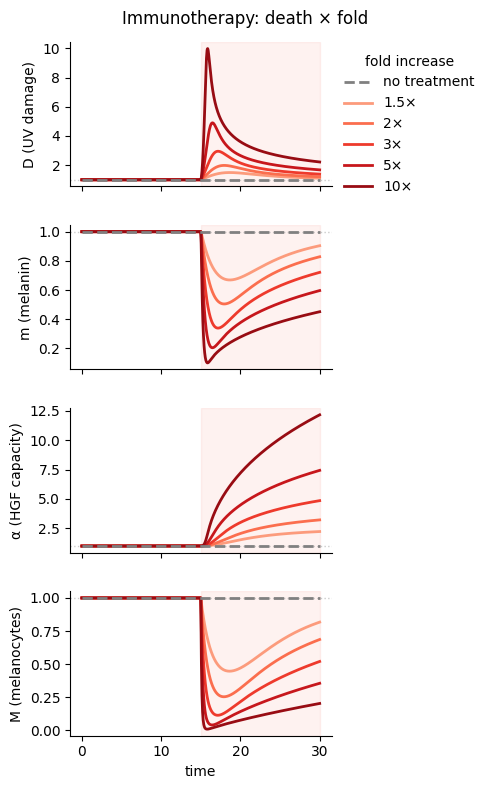

In [5]:
immuno_folds = [1.5, 2, 3, 5, 10]
reds = [plt.get_cmap('Reds')(v) for v in np.linspace(0.35, 0.9, len(immuno_folds))]

fig, axs = plt.subplots(4, 1, figsize=(5, 8), sharex=True)

for i, (ax, label) in enumerate(zip(axs, var_labels)):
    ax.axvspan(duration, duration * 2, alpha=0.1, color='salmon')
    ax.axhline(1, color=GRAY, ls=':', lw=1, alpha=0.4)
    ax.plot(t_base, sol_base[:, i], color=GRAY, lw=2, ls='--', label='no treatment', zorder=5)
    ax.set_ylabel(label)
    sns.despine(ax=ax)

for fold, color in zip(immuno_folds, reds):
    t, sol, _, _ = simulate_treatment(defaults, duration, immuno_fold=fold)
    for i, ax in enumerate(axs):
        ax.plot(t, sol[:, i], color=color, lw=2, label=f'{fold}×')

axs[0].legend(frameon=False, title='fold increase', bbox_to_anchor=(1, 1))
axs[-1].set_xlabel('time')
plt.suptitle('Immunotherapy: death × fold')
plt.tight_layout()
plt.show()

## Treatment combinations

Each main treatment is paired with ×2 / ÷2 modifications of every other model parameter. Both the main treatment and the extra modification are applied simultaneously at `t=duration`.

In [6]:
from matplotlib.lines import Line2D


def simulate_combination(params, duration, braf_fold=1, immuno_fold=1,
                          extra_param=None, extra_fold=1):
    """Main + optional extra parameter modification, both applied at t=duration."""
    x0 = get_steady_state(params)
    p_treat = params.copy()
    if extra_param is not None:
        p_treat[extra_param] *= extra_fold
    t1 = np.linspace(0, duration, 400)
    sol1 = odeint(get_f(params), x0, t1)
    t2 = np.linspace(duration, duration * 2, 400)
    sol2 = odeint(get_f(p_treat, braf_fold=braf_fold, immuno_fold=immuno_fold), sol1[-1], t2)
    return np.concatenate([t1, t2]), np.vstack([sol1, sol2])


def plot_combinations(params, duration, main_kwargs, extra_params, extra_fold=2,
                      title='', color_up='#2166ac', color_down='#92c5de',
                      shade_color='steelblue'):
    n = len(extra_params)
    fig, axs = plt.subplots(n, 4, figsize=(12, 2.2 * n), sharex=True)
    t_ref, sol_ref = simulate_combination(params, duration, **main_kwargs)

    for row, param in enumerate(extra_params):
        for col in range(4):
            ax = axs[row, col]
            ax.axvspan(duration, duration * 2, alpha=0.1, color=shade_color)
            ax.axhline(1, color=GRAY, ls=':', lw=1, alpha=0.3)
            ax.plot(t_ref, sol_ref[:, col], color=GRAY, lw=1.5, ls='--')
            t_up, sol_up = simulate_combination(params, duration, extra_param=param,
                                                 extra_fold=extra_fold, **main_kwargs)
            ax.plot(t_up, sol_up[:, col], color=color_up, lw=2)
            t_dn, sol_dn = simulate_combination(params, duration, extra_param=param,
                                                 extra_fold=1/extra_fold, **main_kwargs)
            ax.plot(t_dn, sol_dn[:, col], color=color_down, lw=2, ls='-.')
            sns.despine(ax=ax)
            if row == 0:
                ax.set_title(var_labels[col], fontsize=9)
            if col == 0:
                ax.set_ylabel(param, fontsize=9)
            if row == n - 1:
                ax.set_xlabel('time', fontsize=8)

    legend_elements = [
        Line2D([0], [0], color=GRAY, lw=1.5, ls='--', label='main treatment only'),
        Line2D([0], [0], color=color_up, lw=2, label=f'×{extra_fold}'),
        Line2D([0], [0], color=color_down, lw=2, ls='-.', label=f'÷{extra_fold}'),
    ]
    axs[0, -1].legend(handles=legend_elements, frameon=False, fontsize=8,
                      bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

### BRAF inhibitor + combinations

Each row: BRAF inhibition (10× pM reduction) alone (gray dashed) vs. additionally multiplying (solid) or dividing (dash-dot) that parameter by 2.

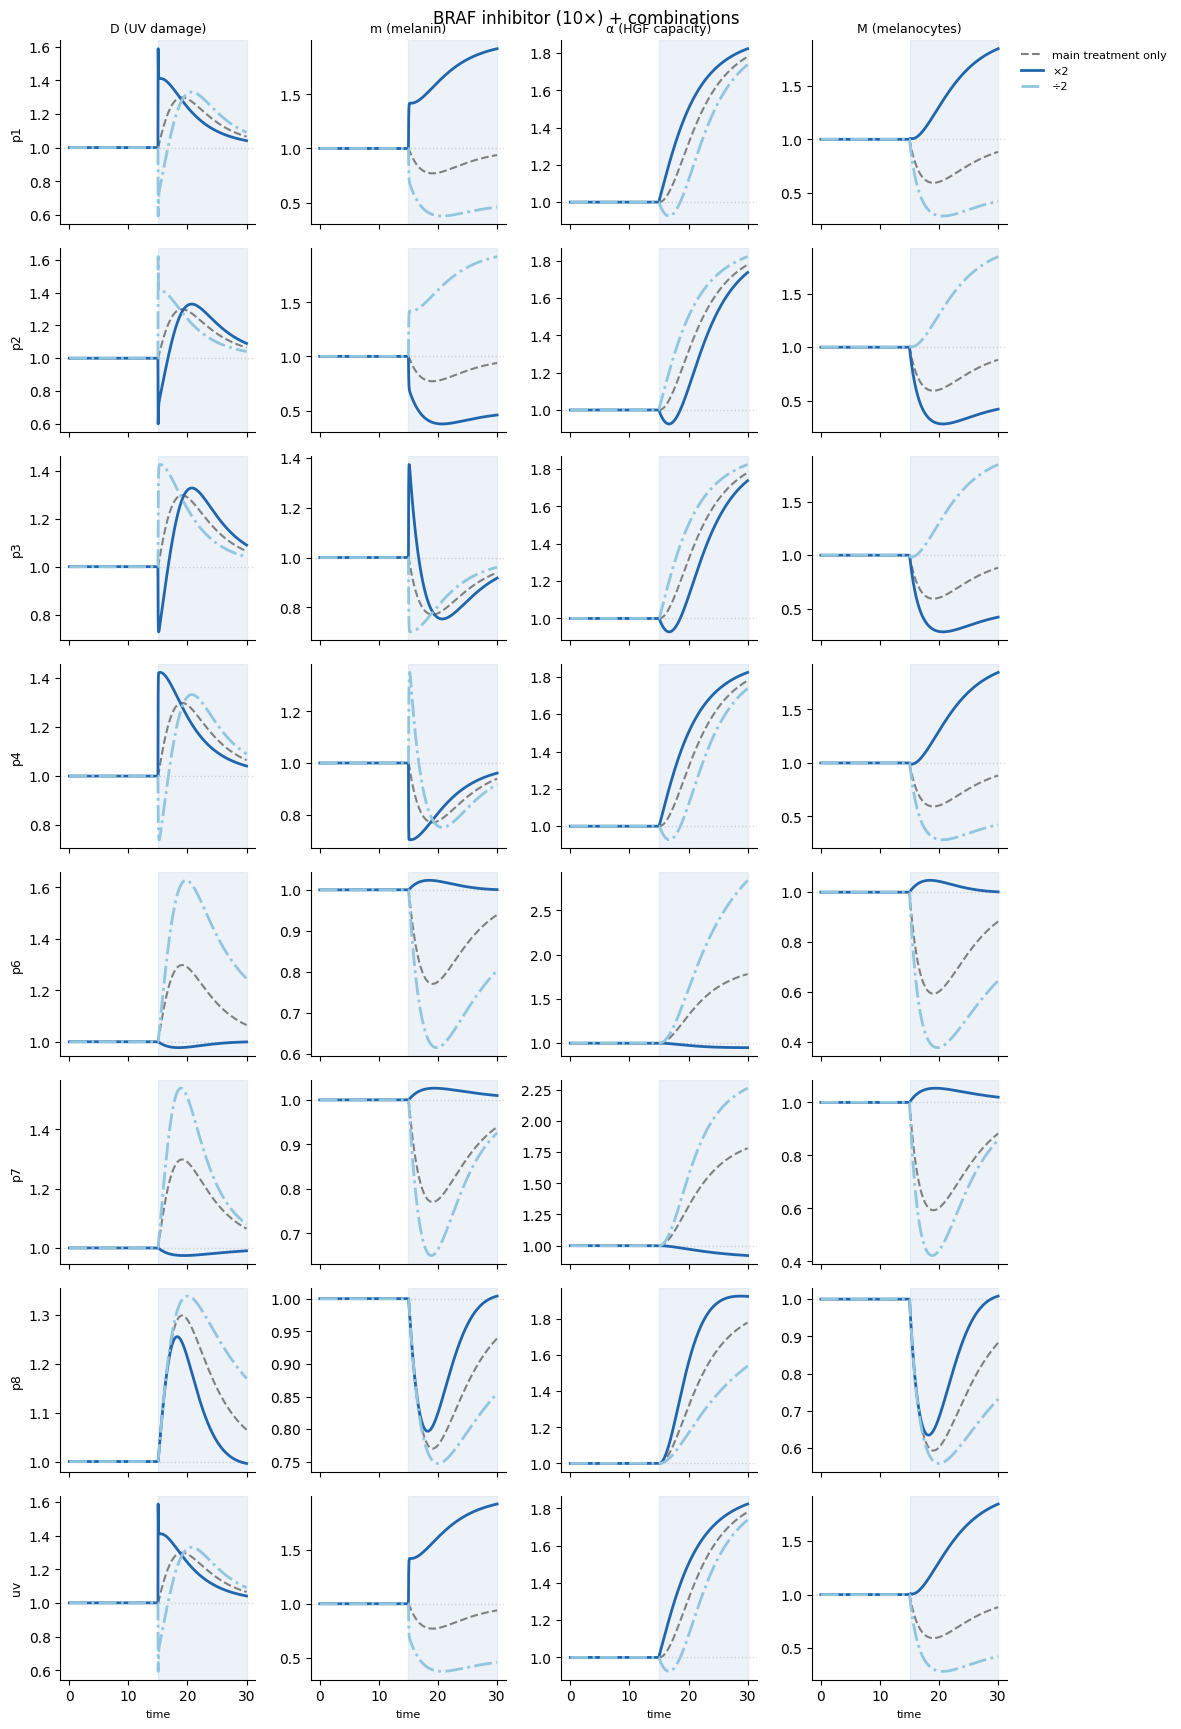

In [7]:
plot_combinations(
    defaults, duration,
    main_kwargs=dict(braf_fold=10),
    extra_params=['p1', 'p2', 'p3', 'p4', 'p6', 'p7', 'p8', 'uv'],
    extra_fold=2,
    title='BRAF inhibitor (10×) + combinations',
    color_up='#2166ac', color_down='#92c5de',
    shade_color='steelblue',
)

```
dD/dτ = ρ₁·UV/m − ρ₂·D
dm/dτ = ρ₃·M·D − ρ₄·m
dα/dτ = ρ₈·(D − 1)              (fibroblast epigenetic memory, D*=1)
dM/dτ = M·(ρ₅/braf + ρ₆·α·D + ρ₇·D − immuno)
```

BRAF combinations that make M decay:
- p1 division, p2 multiplication: less DNA damage from UV
- p3 multiplication, p4 division: more melanin production, protects DNA from UV
- p6 division, p7 division: less melanocytes directly (each block a path)
- p8 division: fibroblasts remember damage slower


### Immunotherapy + combinations

Each row: immunotherapy (3× death) alone (gray dashed) vs. additionally multiplying (solid) or dividing (dash-dot) that parameter by 2.

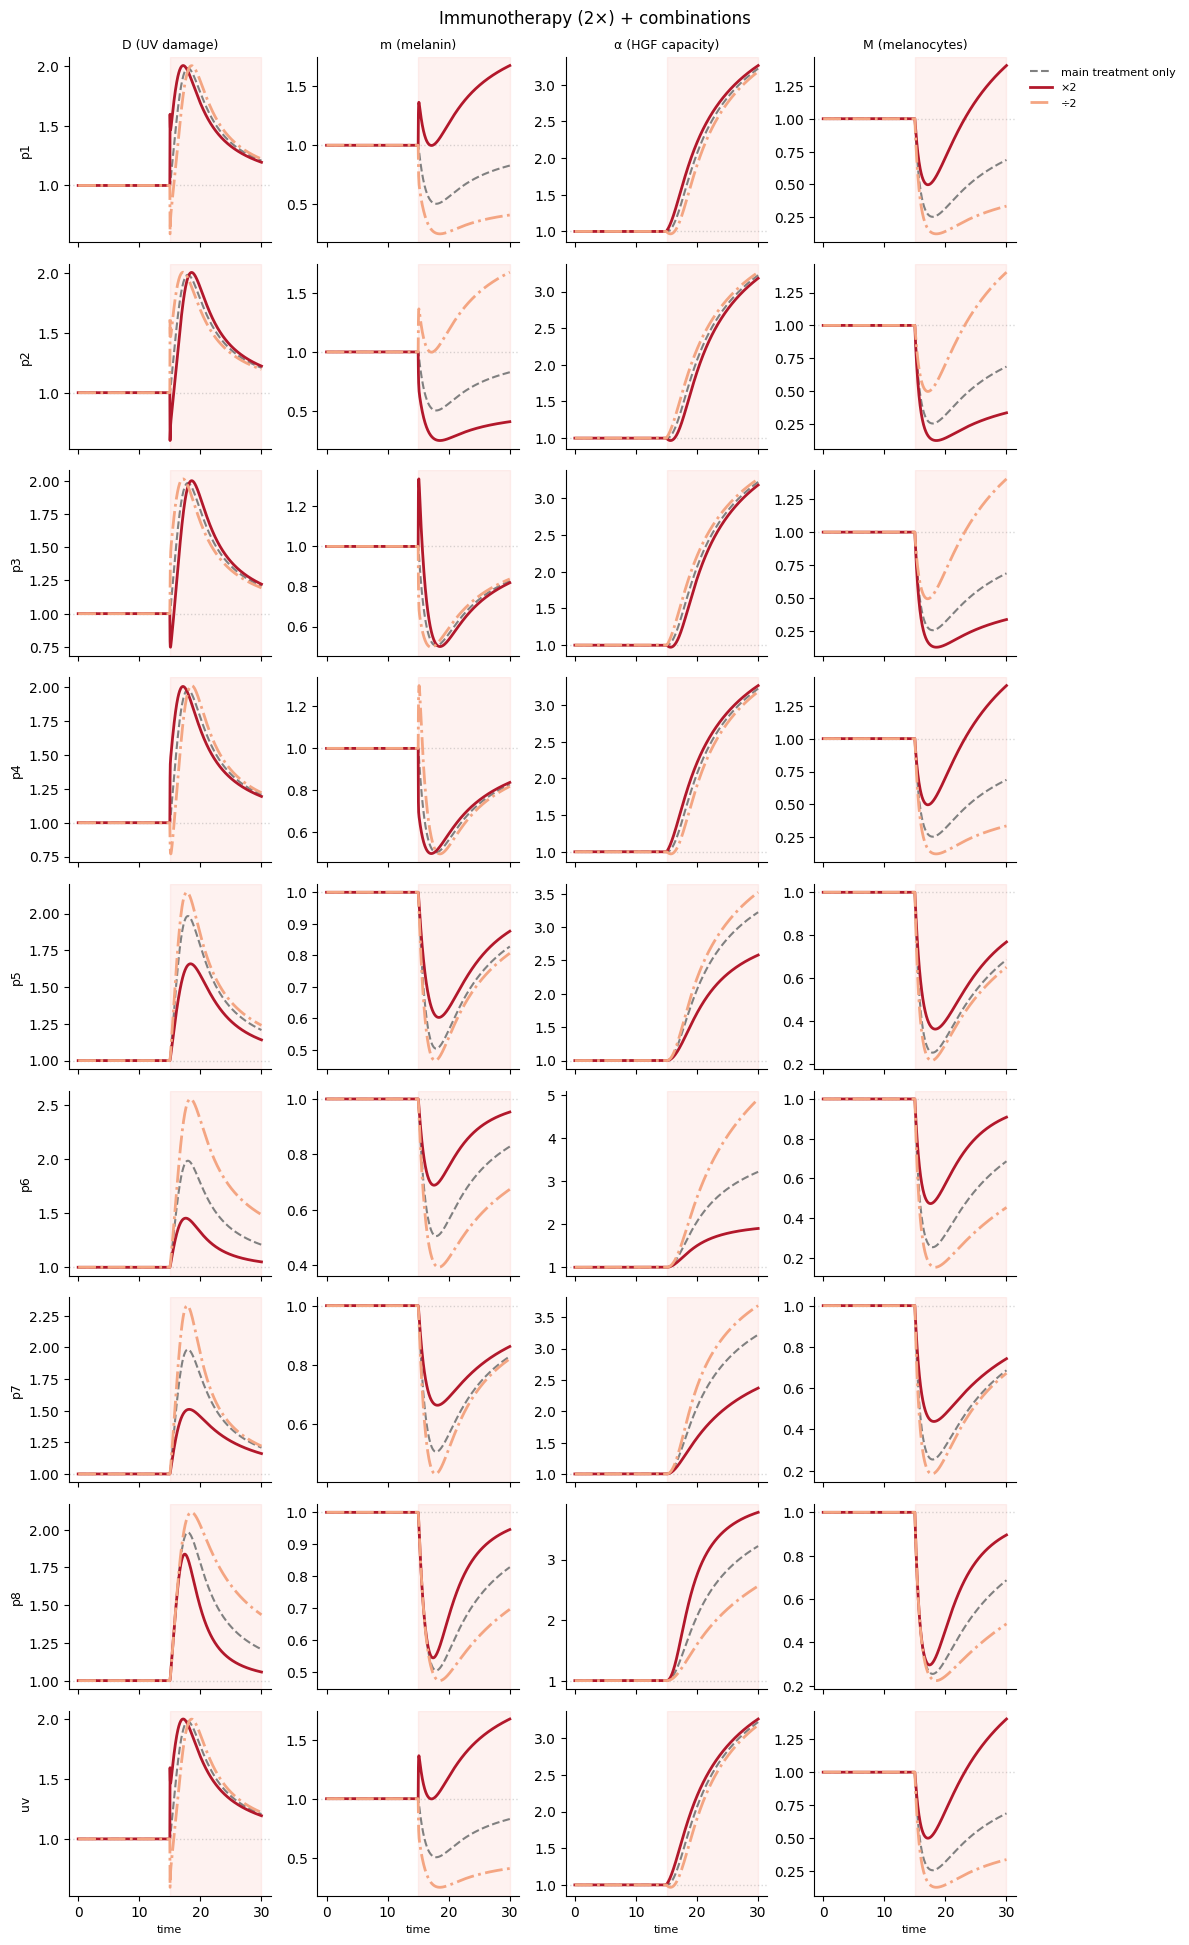

In [8]:
plot_combinations(
    defaults, duration,
    main_kwargs=dict(immuno_fold=2),
    extra_params=['p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'uv'],
    extra_fold=2,
    title='Immunotherapy (2×) + combinations\n',
    color_up='#b2182b', color_down='#f4a582',
    shade_color='salmon',
)

## Preparatory immunotherapy reduction → sharp increase

Before treatment, steadily reduce the death rate below baseline (immuno < 1), letting M expand.
At t=15, sharply apply full immunotherapy. Compare against abrupt immunotherapy with no preparation.

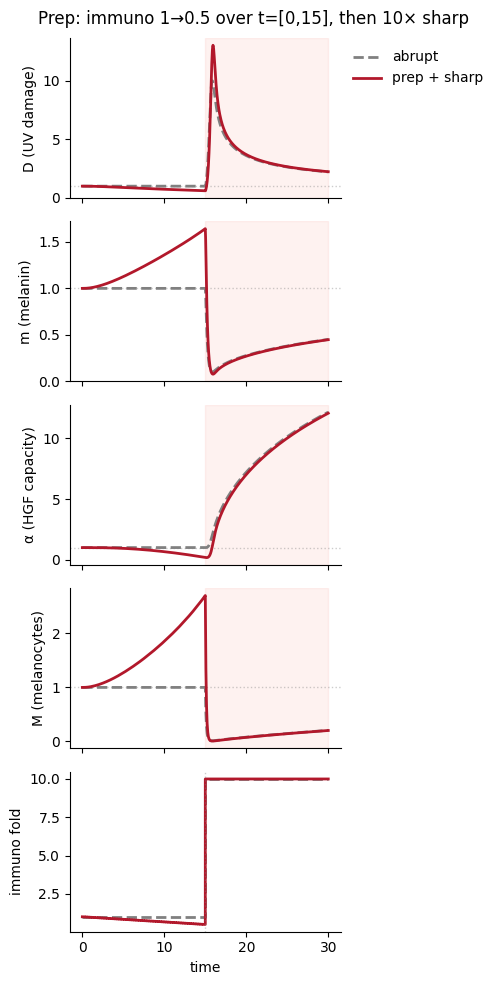

In [9]:
def simulate_prep_then_immuno(params, prep_duration, treat_duration,
                               prep_min=0.3, treat_fold=3, n_steps=100):
    """Phase 1: linearly ramp immuno from 1 down to prep_min over prep_duration.
    Phase 2: sharp jump to treat_fold for treat_duration.
    Returns t, sol, immuno_trace."""
    x_current = get_steady_state(params)
    immuno_ramp = np.linspace(1.0, prep_min, n_steps)
    dt = prep_duration / n_steps

    t_parts, sol_parts, immuno_parts = [], [], []
    t_start = 0.0
    for immuno in immuno_ramp:
        t_step = np.linspace(t_start, t_start + dt, 10)
        sol_step = odeint(get_f(params, immuno_fold=immuno), x_current, t_step)
        t_parts.append(t_step)
        sol_parts.append(sol_step)
        immuno_parts.append(np.full(len(t_step), immuno))
        x_current = sol_step[-1]
        t_start += dt

    t_treat = np.linspace(prep_duration, prep_duration + treat_duration, 400)
    sol_treat = odeint(get_f(params, immuno_fold=treat_fold), x_current, t_treat)

    t = np.concatenate(t_parts + [t_treat])
    sol = np.vstack(sol_parts + [sol_treat])
    immuno_trace = np.concatenate(immuno_parts + [np.full(len(t_treat), treat_fold)])
    return t, sol, immuno_trace


prep_duration = 15
treat_duration = 15
prep_min = 0.5
treat_fold = 10

# Preparatory strategy
t_prep, sol_prep, immuno_prep = simulate_prep_then_immuno(
    defaults, prep_duration, treat_duration, prep_min=prep_min, treat_fold=treat_fold)

# Abrupt immunotherapy (baseline until t=15, then treat_fold)
x0 = get_steady_state(defaults)
t_base_ab = np.linspace(0, prep_duration, 400)
sol_base_ab = odeint(get_f(defaults), x0, t_base_ab)
t_treat_ab = np.linspace(prep_duration, prep_duration + treat_duration, 400)
sol_treat_ab = odeint(get_f(defaults, immuno_fold=treat_fold), sol_base_ab[-1], t_treat_ab)
t_ab = np.concatenate([t_base_ab, t_treat_ab])
sol_ab = np.vstack([sol_base_ab, sol_treat_ab])
immuno_ab = np.concatenate([np.ones(len(t_base_ab)), np.full(len(t_treat_ab), treat_fold)])

fig, axs = plt.subplots(5, 1, figsize=(5, 10), sharex=True)

for i, (ax, label) in enumerate(zip(axs[:4], var_labels)):
    ax.axvspan(prep_duration, prep_duration + treat_duration, alpha=0.1, color='salmon')
    ax.axhline(1, color=GRAY, ls=':', lw=1, alpha=0.4)
    ax.plot(t_ab, sol_ab[:, i], color=GRAY, lw=2, ls='--', label='abrupt')
    ax.plot(t_prep, sol_prep[:, i], color='#b2182b', lw=2, label='prep + sharp')
    ax.set_ylabel(label)
    sns.despine(ax=ax)

ax = axs[4]
ax.plot(t_ab, immuno_ab, color=GRAY, lw=2, ls='--')
ax.plot(t_prep, immuno_prep, color='#b2182b', lw=2)
ax.axvline(prep_duration, color=GRAY, ls=':', lw=1, alpha=0.4)
ax.set_ylabel('immuno fold')
ax.set_xlabel('time')
sns.despine(ax=ax)

axs[0].legend(frameon=False, bbox_to_anchor=(1, 1))
plt.suptitle(f'Prep: immuno 1→{prep_min} over t=[0,{prep_duration}], then {treat_fold}× sharp')
plt.tight_layout()
plt.show()

## Preparatory pM boost → sharp BRAF inhibition

Before treatment, steadily increase pM above baseline (braf_fold < 1 → p5 increases), letting M expand.
At t=15, sharply apply full BRAF inhibition. Compare against abrupt BRAF inhibition with no preparation.

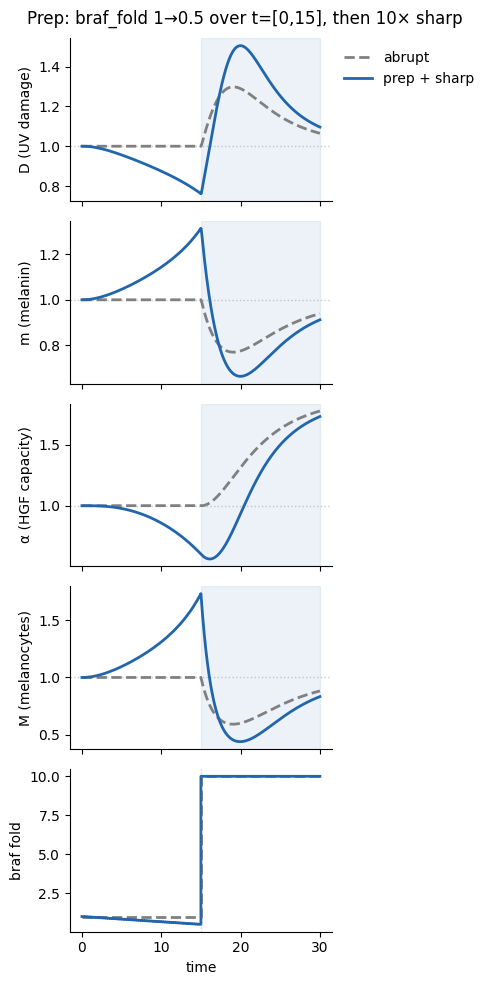

In [10]:
def simulate_prep_then_braf(params, prep_duration, treat_duration,
                             prep_min=0.3, treat_fold=10, n_steps=100):
    """Phase 1: linearly ramp braf_fold from 1 down to prep_min over prep_duration
    (braf_fold < 1 → p5 increases, boosting proliferation).
    Phase 2: sharp jump to treat_fold for treat_duration.
    Returns t, sol, braf_trace."""
    x_current = get_steady_state(params)
    braf_ramp = np.linspace(1.0, prep_min, n_steps)
    dt = prep_duration / n_steps

    t_parts, sol_parts, braf_parts = [], [], []
    t_start = 0.0
    for braf in braf_ramp:
        t_step = np.linspace(t_start, t_start + dt, 10)
        sol_step = odeint(get_f(params, braf_fold=braf), x_current, t_step)
        t_parts.append(t_step)
        sol_parts.append(sol_step)
        braf_parts.append(np.full(len(t_step), braf))
        x_current = sol_step[-1]
        t_start += dt

    t_treat = np.linspace(prep_duration, prep_duration + treat_duration, 400)
    sol_treat = odeint(get_f(params, braf_fold=treat_fold), x_current, t_treat)

    t = np.concatenate(t_parts + [t_treat])
    sol = np.vstack(sol_parts + [sol_treat])
    braf_trace = np.concatenate(braf_parts + [np.full(len(t_treat), treat_fold)])
    return t, sol, braf_trace


prep_duration = 15
treat_duration = 15
prep_min = 0.5
treat_fold = 10

# Preparatory strategy
t_prep, sol_prep, braf_prep = simulate_prep_then_braf(
    defaults, prep_duration, treat_duration, prep_min=prep_min, treat_fold=treat_fold)

# Abrupt BRAF inhibition (baseline until t=15, then treat_fold)
x0 = get_steady_state(defaults)
t_base_ab = np.linspace(0, prep_duration, 400)
sol_base_ab = odeint(get_f(defaults), x0, t_base_ab)
t_treat_ab = np.linspace(prep_duration, prep_duration + treat_duration, 400)
sol_treat_ab = odeint(get_f(defaults, braf_fold=treat_fold), sol_base_ab[-1], t_treat_ab)
t_ab = np.concatenate([t_base_ab, t_treat_ab])
sol_ab = np.vstack([sol_base_ab, sol_treat_ab])
braf_ab = np.concatenate([np.ones(len(t_base_ab)), np.full(len(t_treat_ab), treat_fold)])

fig, axs = plt.subplots(5, 1, figsize=(5, 10), sharex=True)

for i, (ax, label) in enumerate(zip(axs[:4], var_labels)):
    ax.axvspan(prep_duration, prep_duration + treat_duration, alpha=0.1, color='steelblue')
    ax.axhline(1, color=GRAY, ls=':', lw=1, alpha=0.4)
    ax.plot(t_ab, sol_ab[:, i], color=GRAY, lw=2, ls='--', label='abrupt')
    ax.plot(t_prep, sol_prep[:, i], color='#2166ac', lw=2, label='prep + sharp')
    ax.set_ylabel(label)
    sns.despine(ax=ax)

ax = axs[4]
ax.plot(t_ab, braf_ab, color=GRAY, lw=2, ls='--')
ax.plot(t_prep, braf_prep, color='#2166ac', lw=2)
ax.axvline(prep_duration, color=GRAY, ls=':', lw=1, alpha=0.4)
ax.set_ylabel('braf fold')
ax.set_xlabel('time')
sns.despine(ax=ax)

axs[0].legend(frameon=False, bbox_to_anchor=(1, 1))
plt.suptitle(f'Prep: braf_fold 1→{prep_min} over t=[0,{prep_duration}], then {treat_fold}× sharp')
plt.tight_layout()
plt.show()